# 02 · Biological Networks, Regulatory Gates, and Reprogramming

The same exact inverse now meets **real biology**. Genes switch each other on and
off; a *gene-regulatory network* is a Boolean network whose nodes are genes. We
take a published model of the **fission-yeast cell cycle**, recover it from its
behaviour, meet the special **regulatory gate** that biology needs, and then ask
the question a biologist cares about: *which genes, if knocked out, reprogramme the
cell?*

In [1]:
# --- Run me first: make this notebook executable from anywhere -----------------
import os, sys

def _find_root(start=None):
    d = os.path.abspath(start or os.getcwd())
    while True:
        if os.path.isfile(os.path.join(d, "PROTOCOL_order_discovery.md")):
            return d
        parent = os.path.dirname(d)
        if parent == d:
            break
        d = parent
    for cand in [os.path.expanduser("~/Documents/projects/CausalBool/index-deconvolution")]:
        if os.path.isfile(os.path.join(cand, "PROTOCOL_order_discovery.md")):
            return cand
    raise RuntimeError("Could not locate the index-deconvolution root. "
                       "Set ROOT = '/path/to/index-deconvolution' by hand and re-run.")

ROOT = _find_root()
for _sub in ["src", "level2", "level3", "level4", "level5", "level6", "level7", "level8"]:
    _p = os.path.join(ROOT, _sub)
    if _p not in sys.path:
        sys.path.insert(0, _p)

DATA       = os.path.join(ROOT, "finance", "data")          # 23 tickers, 3 years
DATA_LONG  = os.path.join(ROOT, "finance", "data_long")     # 12 instruments, ~30+ years
BIO        = os.path.join(os.path.dirname(ROOT), "data", "bio", "raw")  # .bnet networks

import matplotlib.pyplot as plt
import numpy as np

# a clean, consistent didactic style
plt.rcParams.update({
    "figure.figsize": (9, 4.2), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False,
    "axes.spines.right": False, "font.size": 11, "axes.titlesize": 12,
    "axes.titleweight": "bold", "image.cmap": "magma",
})
INK, HL, OK, BAD = "#20222b", "#c1121f", "#2a9d8f", "#e07a1f"
print("repo root :", ROOT)
print("ready. matplotlib + numpy loaded; code layers on the path.")

repo root : /Users/alberto/Documents/projects/CausalBool/index-deconvolution
ready. matplotlib + numpy loaded; code layers on the path.


## 1. A real gene network

We load a standard model (Davidich & Bornholdt's yeast cell cycle). Its nodes are
real genes and proteins — Cdc25, Cdc2/Cdc13, Wee1, and so on.

In [2]:
from bnet import parse_bnet
from causalbool import repertoire

net, names = parse_bnet(os.path.join(BIO, "pyboolnet_davidich_yeast.bnet"))
print(f"{net.n} genes:", ", ".join(names))
rep = repertoire(net)                 # 2**10 = 1024 states x 10 genes: the full behaviour
print("behaviour table:", len(rep), "states x", len(rep[0]), "genes")

10 genes: Start, Cdc25, Cdc2_Cdc13, Cdc2_Cdc13_A, PP, Rum1, SK, Slp1, Ste9, Wee1_Mik1
behaviour table: 1024 states x 10 genes


## 2. Recover the network, and meet the regulatory gate

Deconvolving the behaviour recovers each gene's regulators and its logic. Biology
rarely uses tidy AND/OR gates; its workhorse is **activators AND NOT inhibitors** —
a gene turns on when its activators are present *and* its repressors are absent.
Our method names this the **REGULATORY** gate, and unions of such clauses the
**REGULATORY_DNF** gate.

In [3]:
from deconvolution import deconvolve, verify_forward
from collections import Counter

net2, reports = deconvolve(rep)
gate_counts = Counter(r.canonical.gate for r in reports)

print("recovered logic, gene by gene:")
for r, nm in zip(reports, names):
    regs = [names[i] for i in r.connected_inputs]
    print(f"  {nm:14s} <- {r.canonical.gate:14s} of {regs}")
print("\nexact behavioural match:", repertoire(net2) == rep, "| independent rebuild:", verify_forward(rep, net2))

recovered logic, gene by gene:
  Start          <- FALSE          of []
  Cdc25          <- REGULATORY_DNF of ['Cdc25', 'Cdc2_Cdc13', 'PP']
  Cdc2_Cdc13     <- NOR            of ['Rum1', 'Slp1', 'Ste9']
  Cdc2_Cdc13_A   <- REGULATORY     of ['Cdc25', 'Rum1', 'Slp1', 'Ste9', 'Wee1_Mik1']
  PP             <- AND            of ['Slp1']
  Rum1           <- REGULATORY_DNF of ['Cdc2_Cdc13', 'Cdc2_Cdc13_A', 'PP', 'Rum1', 'SK']
  SK             <- AND            of ['Start']
  Slp1           <- AND            of ['Cdc2_Cdc13_A']
  Ste9           <- REGULATORY_DNF of ['Cdc2_Cdc13', 'Cdc2_Cdc13_A', 'PP', 'SK', 'Ste9']
  Wee1_Mik1      <- REGULATORY_DNF of ['Cdc2_Cdc13', 'PP', 'Wee1_Mik1']

exact behavioural match: True | independent rebuild: {'exact': True, 'mismatched_nodes': [], 'n_nodes': 10, 'repertoire_rows': 1024}


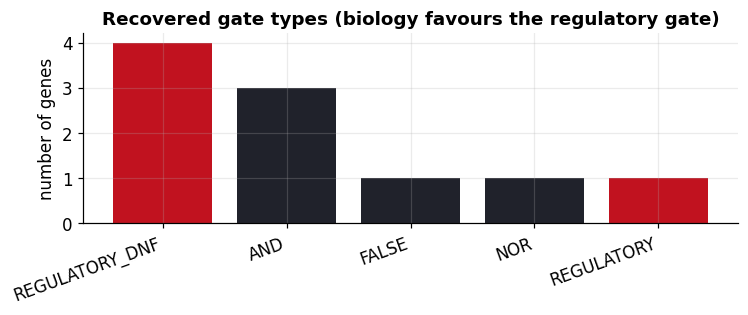

In [4]:
fig, ax = plt.subplots(figsize=(7, 3))
labels, vals = zip(*gate_counts.most_common())
ax.bar(labels, vals, color=[HL if "REGULATORY" in l else INK for l in labels])
ax.set_ylabel("number of genes"); ax.set_title("Recovered gate types (biology favours the regulatory gate)")
plt.xticks(rotation=20, ha="right"); plt.tight_layout(); plt.show()

### What a regulatory gate looks like

For a gene named **REGULATORY**, the recovered rule marks each regulator as an
*activator* or an *inhibitor*. The gene fires only when every activator is ON and
every inhibitor is OFF.

In [5]:
for r, nm in zip(reports, names):
    if r.canonical.gate == "REGULATORY":
        acts = [names[r.connected_inputs[j]] for j in r.canonical.params["activators"]]
        inhs = [names[r.connected_inputs[j]] for j in range(len(r.connected_inputs))
                if j not in r.canonical.params["activators"]]
        print(f"{nm}  fires when  activators {acts} are ON  AND  inhibitors {inhs} are OFF")

Cdc2_Cdc13_A  fires when  activators ['Cdc25'] are ON  AND  inhibitors ['Rum1', 'Slp1', 'Ste9', 'Wee1_Mik1'] are OFF


## 3. Behavioural equivalence, in a picture

The recovered network reproduces all 1024 states. We show the two behaviour tables
and their difference (a thin slice, so it fits on screen).

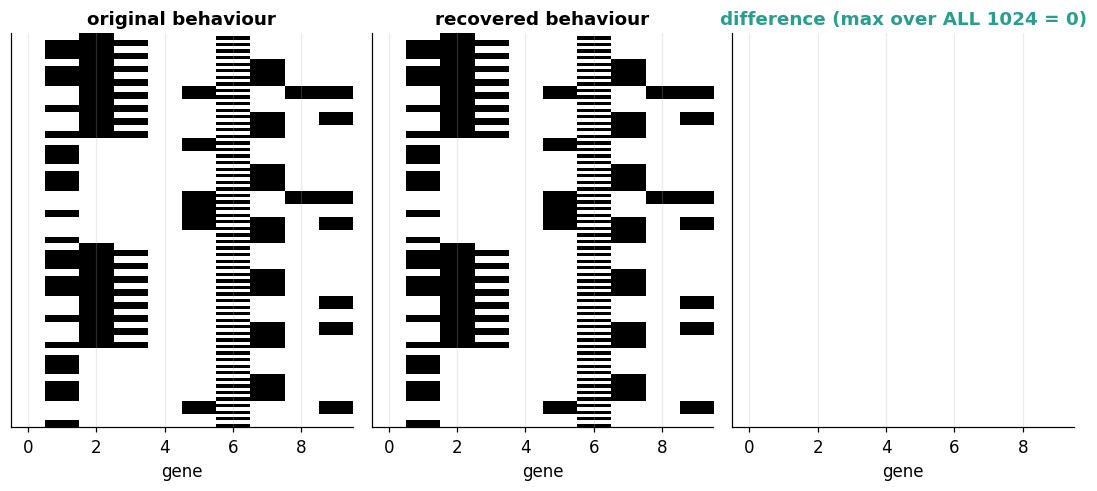

In [6]:
rep_a = np.array(rep); rep_b = np.array(repertoire(net2))
sl = slice(0, 120)                          # first 120 of 1024 states, to see the pixels
fig, axes = plt.subplots(1, 3, figsize=(10, 4.6))
for ax, M, t in zip(axes, [rep_a[sl], rep_b[sl], np.abs(rep_a[sl]-rep_b[sl])],
                    ["original behaviour", "recovered behaviour", "difference"]):
    ax.imshow(M, cmap="Greys", vmin=0, vmax=1, aspect="auto")
    ax.set_title(t); ax.set_xlabel("gene"); ax.set_yticks([])
axes[2].set_title(f"difference (max over ALL 1024 = {int(np.abs(rep_a-rep_b).max())})", color=OK)
plt.tight_layout(); plt.show()

## 4. Reprogramming: which genes are the drivers?

Because we hold the *exact* dynamics, we can ask a causal question directly. Fix a
gene OFF (a **knockout**) and re-measure two things:

* the **image size** — how many distinct next-states the system can reach (its
  dynamical richness);
* the **number of attractors** — the stable fates (cell-cycle phases) it can settle
  into.

Genes whose knockout changes these the most are the **drivers** — the levers of the
cell. This reproduces the logic of cellular-reprogramming studies, exactly.

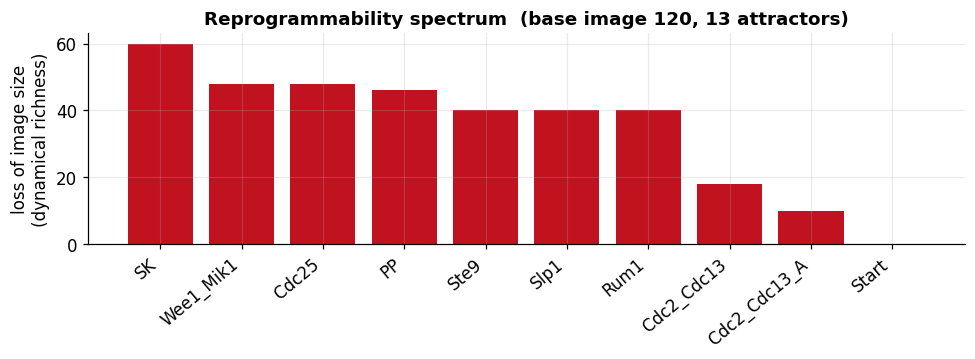

top drivers by dynamical impact: ['SK', 'Wee1_Mik1', 'Cdc25']


In [7]:
from reprogramming import spectrum, image_size, num_attractors

base_img, base_att = image_size(net), num_attractors(net)
info_img = spectrum(net, measure=image_size)          # drop in image size per knockout
info_att = spectrum(net, measure=num_attractors)      # drop in #attractors per knockout
order = np.argsort(info_img)[::-1]

fig, ax = plt.subplots(figsize=(9, 3.4))
xs = np.arange(net.n)
ax.bar(xs, [info_img[i] for i in order], color=HL)
ax.set_xticks(xs); ax.set_xticklabels([names[i] for i in order], rotation=40, ha="right")
ax.set_ylabel("loss of image size\n(dynamical richness)")
ax.set_title(f"Reprogrammability spectrum  (base image {base_img}, {base_att} attractors)")
plt.tight_layout(); plt.show()
drivers = [names[i] for i in order if info_img[i] > 0][:3]
print("top drivers by dynamical impact:", drivers)

## Takeaways

* Real gene networks are recovered **exactly** from their behaviour, gene by gene.
* Biology's natural logic is the **regulatory gate** (activators AND NOT
  inhibitors); we name it, and compress unions of such clauses as REGULATORY_DNF.
* Holding the exact dynamics lets us **reprogramme** *in silico*: knock a gene out,
  watch the attractor landscape move, and read off the driver genes.

**Next (03):** we point the very same machine at **financial markets** — and get an
honest, informative *failure* that reshapes the whole question.